# wm_dataset.ipynb

Notebook minimal et lisible pour générer un premier dataset `wm_colab`.

Objectifs :

- détecter local / Google Colab
- monter Google Drive si besoin
- utiliser `src.env`
- générer un mini dataset de transitions
- sauvegarder un `.npz`
- recharger le dataset depuis le disque
- faire quelques vérifications simples
- afficher quelques exemples visuels

Ce notebook est volontairement simple.
On cherche d'abord à valider le pipeline de génération avant d'ajouter plus de stats.

## 1. Setup environnement

En local :
- sauvegarde dans `./local_runs/datasets`

Dans Colab :
- sauvegarde dans `Mon Drive/projetColab/wm_colab/datasets`

In [ ]:
import sys
import subprocess
import shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    repo_dir = Path("/content/wm_colab")
    if not repo_dir.exists():
        subprocess.run(
            ["git", "clone", "https://github.com/Stabadev/wm_colab.git", str(repo_dir)],
            check=True,
        )
    else:
        subprocess.run(["git", "-C", str(repo_dir), "pull"], check=True)

    # Purge le cache .pyc pour forcer le rechargement du code à jour
    shutil.rmtree(repo_dir / "src" / "__pycache__", ignore_errors=True)
    sys.path.insert(0, str(repo_dir))

    BASE_DIR = Path("/content/drive/MyDrive/projetColab/wm_colab")
else:
    BASE_DIR = Path("./local_runs")

DATASET_DIR    = BASE_DIR / "datasets"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"

DATASET_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB   = {IN_COLAB}")
print(f"BASE_DIR   = {BASE_DIR}")
print(f"DATASET_DIR= {DATASET_DIR}")
print(f"CKPT_DIR   = {CHECKPOINT_DIR}")

## 2. Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from src.env import RenderConfig, GridWorld, precalculate_render, render_obs

/home/alexandre/anaconda3/envs/wm_colab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Configuration

Commence avec un petit dataset pour valider le notebook.

Quand tout sera stable, tu pourras augmenter `N_TRANSITIONS`.

In [3]:
# Board
N = 5
N_ACTIONS = 4

# Dataset
N_TRANSITIONS = 5_000
RESET_EVERY = 200
SEED = 42

# Rendu
CFG = RenderConfig(
    N=N,
    az_deg=203,
    el_deg=32,
    margin_pct=1,
    render_size=128,
    gray_agent=141,
    gray_target=60,
    pad_agent=0.32,
    line_w=1.2,
    color_board=(210, 235, 228),
    color_line=(17, 17, 17),
)

# Nom de fichier
DATASET_NAME = f"dataset_iso_N{N}_{N_TRANSITIONS//1000}k.npz"
DATASET_PATH = DATASET_DIR / DATASET_NAME

np.random.seed(SEED)

print(f"Board          : {N}x{N}")
print(f"N_TRANSITIONS  : {N_TRANSITIONS:,}")
print(f"RESET_EVERY    : {RESET_EVERY}")
print(f"RENDER_SIZE    : {CFG.render_size}")
print(f"DATASET_PATH   : {DATASET_PATH}")

Board          : 5x5
N_TRANSITIONS  : 5,000
RESET_EVERY    : 200
RENDER_SIZE    : 128
DATASET_PATH   : local_runs/datasets/dataset_iso_N5_5k.npz


## 4. Génération du dataset

Chaque transition contient :

- `obs_t`
- `action`
- `obs_t1`
- `agent_t`
- `agent_t1`
- `target`

In [4]:
cache = precalculate_render(CFG)
env = GridWorld(N=N)

obs_t_all    = np.zeros((N_TRANSITIONS, CFG.render_size, CFG.render_size), dtype=np.uint8)
actions_all  = np.zeros((N_TRANSITIONS,), dtype=np.int64)
obs_t1_all   = np.zeros((N_TRANSITIONS, CFG.render_size, CFG.render_size), dtype=np.uint8)
agent_t_all  = np.zeros((N_TRANSITIONS, 2), dtype=np.int8)
agent_t1_all = np.zeros((N_TRANSITIONS, 2), dtype=np.int8)
target_all   = np.zeros((N_TRANSITIONS, 2), dtype=np.int8)

agent, target = env.reset()

for i in tqdm(range(N_TRANSITIONS), desc="Generation dataset"):
    if i % RESET_EVERY == 0:
        agent, target = env.reset()

    obs_t = render_obs(agent, target, cache)
    action = np.random.randint(N_ACTIONS)
    agent_next, target_next, done = env.step(action)
    obs_t1 = render_obs(agent_next, target_next, cache)

    obs_t_all[i] = obs_t
    actions_all[i] = action
    obs_t1_all[i] = obs_t1
    agent_t_all[i] = agent
    agent_t1_all[i] = agent_next
    target_all[i] = target

    agent, target = agent_next, target_next

print("Generation terminee.")

Generation dataset: 100%|██████████████████████████████████| 5000/5000 [00:00<00:00, 8217.58it/s]

Generation terminee.


## 5. Vérifications mémoire rapides

In [5]:
print("obs_t_all   :", obs_t_all.shape, obs_t_all.dtype)
print("actions_all :", actions_all.shape, actions_all.dtype)
print("obs_t1_all  :", obs_t1_all.shape, obs_t1_all.dtype)
print("agent_t_all :", agent_t_all.shape, agent_t_all.dtype)
print("agent_t1_all:", agent_t1_all.shape, agent_t1_all.dtype)
print("target_all  :", target_all.shape, target_all.dtype)

print("\nPremiere transition :")
print("  agent_t  =", tuple(agent_t_all[0]))
print("  action   =", int(actions_all[0]))
print("  agent_t1 =", tuple(agent_t1_all[0]))
print("  target   =", tuple(target_all[0]))

obs_t_all   : (5000, 128, 128) uint8
actions_all : (5000,) int64
obs_t1_all  : (5000, 128, 128) uint8
agent_t_all : (5000, 2) int8
agent_t1_all: (5000, 2) int8
target_all  : (5000, 2) int8

Premiere transition :
  agent_t  = (np.int8(4), np.int8(1))
  action   = 2
  agent_t1 = (np.int8(3), np.int8(1))
  target   = (np.int8(2), np.int8(2))


## 6. Sauvegarde du dataset

In [6]:
np.savez_compressed(
    DATASET_PATH,
    obs_t=obs_t_all,
    actions=actions_all,
    obs_t1=obs_t1_all,
    agent_t=agent_t_all,
    agent_t1=agent_t1_all,
    target=target_all,
)

size_mb = DATASET_PATH.stat().st_size / 1e6
print(f"Dataset sauvegarde : {DATASET_PATH}")
print(f"Taille            : {size_mb:.2f} Mo")

Dataset sauvegarde : local_runs/datasets/dataset_iso_N5_5k.npz
Taille            : 4.24 Mo


## 7. Test de rechargement depuis le disque

On recharge immédiatement le `.npz` pour valider :
- que l'écriture s'est bien passée
- qu'on saura relire le dataset plus tard, en local comme dans Colab

In [7]:
loaded = np.load(DATASET_PATH)

obs_t_loaded    = loaded["obs_t"]
actions_loaded  = loaded["actions"]
obs_t1_loaded   = loaded["obs_t1"]
agent_t_loaded  = loaded["agent_t"]
agent_t1_loaded = loaded["agent_t1"]
target_loaded   = loaded["target"]

print("Reload OK.")
print("obs_t_loaded   :", obs_t_loaded.shape, obs_t_loaded.dtype)
print("actions_loaded :", actions_loaded.shape, actions_loaded.dtype)
print("obs_t1_loaded  :", obs_t1_loaded.shape, obs_t1_loaded.dtype)
print("agent_t_loaded :", agent_t_loaded.shape, agent_t_loaded.dtype)
print("agent_t1_loaded:", agent_t1_loaded.shape, agent_t1_loaded.dtype)
print("target_loaded  :", target_loaded.shape, target_loaded.dtype)

Reload OK.
obs_t_loaded   : (5000, 128, 128) uint8
actions_loaded : (5000,) int64
obs_t1_loaded  : (5000, 128, 128) uint8
agent_t_loaded : (5000, 2) int8
agent_t1_loaded: (5000, 2) int8
target_loaded  : (5000, 2) int8


## 8. Vérifications simples après reload

In [8]:
assert obs_t_loaded.shape == (N_TRANSITIONS, CFG.render_size, CFG.render_size)
assert obs_t1_loaded.shape == (N_TRANSITIONS, CFG.render_size, CFG.render_size)
assert actions_loaded.shape == (N_TRANSITIONS,)
assert agent_t_loaded.shape == (N_TRANSITIONS, 2)
assert agent_t1_loaded.shape == (N_TRANSITIONS, 2)
assert target_loaded.shape == (N_TRANSITIONS, 2)

assert obs_t_loaded.dtype == np.uint8
assert obs_t1_loaded.dtype == np.uint8
assert actions_loaded.dtype == np.int64

assert actions_loaded.min() >= 0
assert actions_loaded.max() < N_ACTIONS

print("Assertions OK.")

Assertions OK.


## 9. Quelques stats simples

In [9]:
agent_moved = ~np.all(agent_t_loaded == agent_t1_loaded, axis=1)
collision_count = (~agent_moved).sum()
move_count = agent_moved.sum()

print(f"Transitions totales : {N_TRANSITIONS:,}")
print(f"Deplacements        : {move_count:,}")
print(f"Collisions bord     : {collision_count:,}")

action_counts = np.bincount(actions_loaded, minlength=N_ACTIONS)
print("\nDistribution des actions :")
for a, c in enumerate(action_counts):
    print(f"  action {a}: {c}")

Transitions totales : 5,000
Deplacements        : 3,976
Collisions bord     : 1,024

Distribution des actions :
  action 0: 1297
  action 1: 1238
  action 2: 1215
  action 3: 1250


## 10. Visualisation de quelques transitions

Affiche quelques paires `obs_t / obs_t1`.

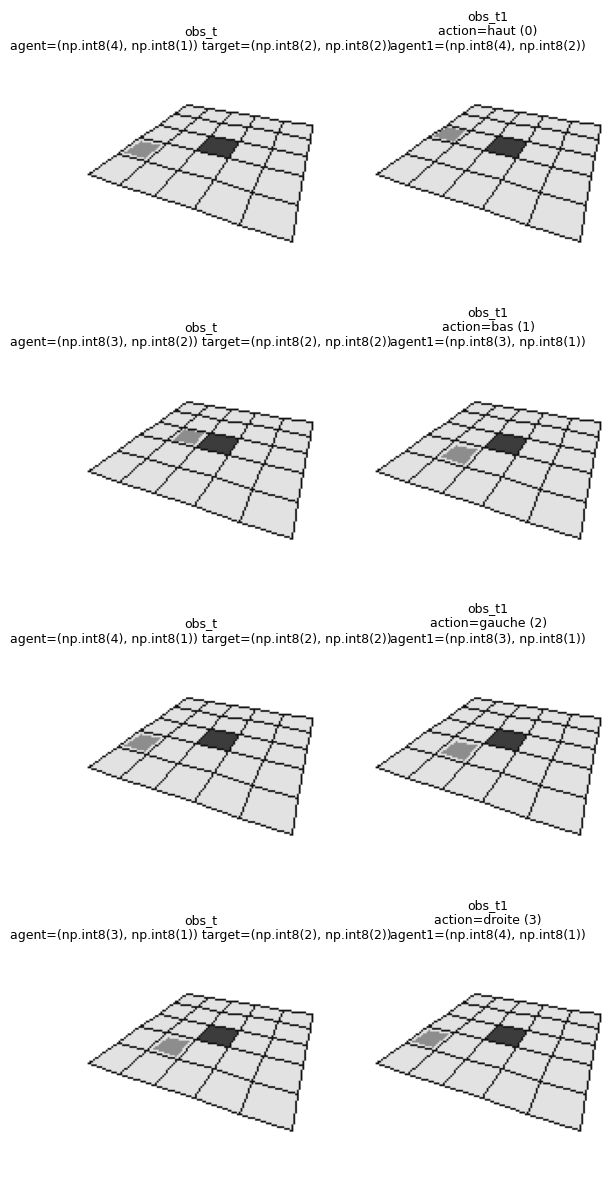

In [11]:
ACTION_NAMES = {
    0: "haut",
    1: "bas",
    2: "gauche",
    3: "droite",
}

# trouver un index pour chaque action
indices = []
for action in range(N_ACTIONS):
    idx = np.where(actions_loaded == action)[0][0]  # premier match
    indices.append(idx)

fig, axes = plt.subplots(len(indices), 2, figsize=(6, 3 * len(indices)))

for row_idx, idx in enumerate(indices):
    action = int(actions_loaded[idx])

    axes[row_idx, 0].imshow(obs_t_loaded[idx], cmap="gray", vmin=0, vmax=255)
    axes[row_idx, 0].set_title(
        f"obs_t\nagent={tuple(agent_t_loaded[idx])} target={tuple(target_loaded[idx])}",
        fontsize=9
    )
    axes[row_idx, 0].axis("off")

    axes[row_idx, 1].imshow(obs_t1_loaded[idx], cmap="gray", vmin=0, vmax=255)
    axes[row_idx, 1].set_title(
        f"obs_t1\naction={ACTION_NAMES[action]} ({action})\nagent1={tuple(agent_t1_loaded[idx])}",
        fontsize=9
    )
    axes[row_idx, 1].axis("off")

plt.tight_layout()
plt.show()

## 11. Heatmaps positions agent / cible

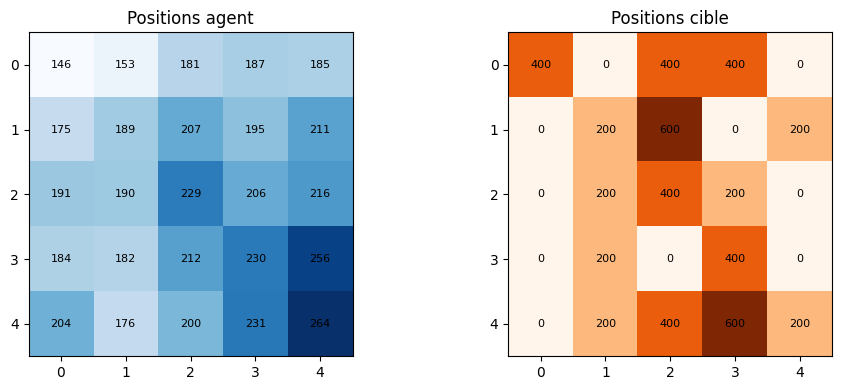

In [12]:
hm_agent = np.zeros((N, N), dtype=np.int32)
hm_target = np.zeros((N, N), dtype=np.int32)

for c, r in agent_t_loaded:
    hm_agent[r, c] += 1

for c, r in target_loaded:
    hm_target[r, c] += 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(hm_agent, cmap="Blues")
axes[0].set_title("Positions agent")
for r in range(N):
    for c in range(N):
        axes[0].text(c, r, str(hm_agent[r, c]), ha="center", va="center", fontsize=8)

axes[1].imshow(hm_target, cmap="Oranges")
axes[1].set_title("Positions cible")
for r in range(N):
    for c in range(N):
        axes[1].text(c, r, str(hm_target[r, c]), ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 12. Résumé final

Si tout s'est bien passé, tu as maintenant un premier dataset généré et relu avec succès.

En local :
- `./local_runs/datasets/...`

Dans Colab :
- `Mon Drive/projetColab/wm_colab/datasets/...`

In [ ]:
print("Fichier final :")
print(DATASET_PATH)
print(f"Existe : {DATASET_PATH.exists()}")
if DATASET_PATH.exists():
    print(f"Taille : {DATASET_PATH.stat().st_size / 1e6:.2f} Mo")